# Single-Agent Leadership POMDP

This notebook implements a simplified single-agent POMDP version of the leadership emergence game. Instead of modeling both agents as strategic reasoners (I-POMDP), we model one agent (Alice) as a strategic POMDP solver, while the other agent (Bob) acts according to a simple behavioral rule based on his role type.

## Problem Setup

**Scenario**: Alice is working with Bob on a collaborative project. Bob has an underlying role preference (Leader or Follower) that Alice doesn't know. Bob acts according to his role:
- **Leader Bob**: Tends to Assert (80% of the time)
- **Follower Bob**: Tends to Defer (80% of the time)

**Alice's Goal**: Learn Bob's true role type through interaction and choose actions that maximize coordination payoffs.

## POMDP Components

**States (S)**: Bob's true role type
- `Follower`: Bob is naturally a follower
- `Leader`: Bob is naturally a leader

**Actions (A)**: Alice's choices
- `Defer`: Let Bob take the lead
- `Assert`: Take the lead herself

**Observations (Ω)**: What Alice sees Bob do
- `ObserveDefer`: Alice sees Bob defer
- `ObserveAssert`: Alice sees Bob assert

**Transition Function (T)**: Bob's role is static (doesn't change over time)
- Identity function: roles remain constant

**Observation Function (O)**: Bob's action probabilities given his role
- Leader Bob: 80% Assert, 20% Defer
- Follower Bob: 80% Defer, 20% Assert

**Reward Function (R)**: Coordination game payoffs
- Both coordinate (one asserts, one defers): +1.0
- Both defer (indecision): +0.5
- Both assert (conflict): 0.0

Since Bob's action is probabilistic, we compute **expected reward** given Bob's role and Alice's action.

## Key Insights

Unlike the Tiger POMDP where there's a dedicated "Listen" action, here Alice learns about Bob's role **through repeated interaction**. Every action Alice takes produces an observation (Bob's response), which Alice uses to update her belief about Bob's role type.

This captures the essence of social learning: we discover others' preferences and tendencies through observing how they respond to our actions.

In [7]:
from memo import memo, domain
import jax
import jax.numpy as np

In [8]:
from enum import IntEnum

class S(IntEnum):
    Follower = 0;
    Leader = 1;

class A(IntEnum):
    Defer = 0;
    Assert = 1;

class O(IntEnum):
    ObserveDefer = 0
    ObserveAssert = 1


# Belief space, discretized into 50 possible belief states
# b represents P(Bob is Leader)
# 1 = 100% confidence Bob is a leader
# 0 = 100% confidence Bob is a follower
B = np.linspace(0, 1, 50)  

@jax.jit
def get_belief(b, s):
    """
    Get probability of state s given belief b.
    """
    # Array: [P(Bob is Follower), P(Bob is Leader)]
    belief_probs = np.array([1.0 - b, b])
    return belief_probs[s]

@jax.jit
def Tr(s, a, s_):
    """
    Transition function: P(s' | s, a)
    
    Bob's role type is static - it doesn't change over time.
    So the transition function is deterministic identity.
    
    Args:
        s: Current state (Bob's role)
        a: Action taken by Alice
        s_: Next state (Bob's role)
    
    Returns:
        Probability of transitioning to s_ given s and a
    """
    # Both actions result in no state change
    # Identity matrix for both Defer and Assert
    identity_trans = np.array([
        [1.0, 0.0],  # Follower stays Follower
        [0.0, 1.0]   # Leader stays Leader
    ])

    # Stack into 3D array: [action, current_state, next_state]
    trans_matrix = np.stack([
        identity_trans,  # Action 0: Defer
        identity_trans   # Action 1: Assert
    ])

    return trans_matrix[a, s, s_]

@jax.jit
def get_bob_action_prob(bob_role, bob_action):
    """
    Helper function: P(Bob's action | Bob's role)
    
    Bob acts according to his role type:
    - Leader types tend to Assert (80% Assert, 20% Defer)
    - Follower types tend to Defer (80% Defer, 20% Assert)
    """
    # Rows: Bob's role [Follower, Leader]
    # Cols: Bob's action [Defer, Assert]
    action_prob_matrix = np.array([
        [0.8, 0.2],  # Follower: 80% Defer, 20% Assert
        [0.2, 0.8]   # Leader: 80% Assert, 20% Defer
    ])
    return action_prob_matrix[bob_role, bob_action]

@jax.jit
def Obs(o, s, a):
    """
    Observation function: P(o | s, a)
    
    Alice observes Bob's action. Bob's action depends on his role type.
    So this encodes: P(observe Bob do action_o | Bob's role is s, Alice did a)
    
    For simplicity, we assume Bob's response is independent of Alice's action
    (Bob just acts according to his role type).
    
    Args:
        o: Observation (0=ObserveDefer, 1=ObserveAssert)
        s: Bob's true role (0=Follower, 1=Leader)
        a: Alice's action (0=Defer, 1=Assert)
    
    Returns:
        Probability of observation o given state s and action a
    """
    # Bob's behavior based on his role (independent of Alice's action)
    # Rows: Bob's role [Follower, Leader]
    # Cols: Observation [ObserveDefer, ObserveAssert]
    bob_behavior = np.array([
        [0.8, 0.2],  # Follower Bob: 80% Defer, 20% Assert
        [0.2, 0.8]   # Leader Bob: 80% Assert, 20% Defer
    ])

    # Same observation probabilities for both of Alice's actions
    # Stack into 3D array: [action, state, observation]
    obs_matrix = np.stack([
        bob_behavior,  # Action 0: Alice Defer
        bob_behavior   # Action 1: Alice Assert
    ])

    return obs_matrix[a, s, o]

@jax.jit
def R(s, a):
    """
    Reward function: Expected reward given Bob's role and Alice's action.
    
    The immediate reward depends on the action pair (Alice's action, Bob's action).
    Since Bob's action is probabilistic based on his role, we compute expected reward.
    
    Coordination game payoffs:
    - (Assert, Defer) or (Defer, Assert): +1.0 (coordination)
    - (Defer, Defer): +0.5 (indecision)
    - (Assert, Assert): 0.0 (conflict)
    
    Args:
        s: Bob's role (0=Follower, 1=Leader)
        a: Alice's action (0=Defer, 1=Assert)
    
    Returns:
        Expected immediate reward
    """
    # Payoff matrix: [Alice's action, Bob's action]
    payoff_matrix = np.array([
        [0.5, 1.0],  # Alice Defer: 0.5 if Bob defers, 1.0 if Bob asserts
        [1.0, 0.0]   # Alice Assert: 1.0 if Bob defers, 0.0 if Bob asserts
    ])
    
    # Expected reward = sum over Bob's possible actions weighted by probability
    expected_reward = 0.0
    for bob_action in [0, 1]:  # Defer, Assert
        prob_bob_action = get_bob_action_prob(s, bob_action)
        reward = payoff_matrix[a, bob_action]
        expected_reward += prob_bob_action * reward
    
    return expected_reward

In [9]:
# Test the component functions
print("Testing game components...")
print("\nTransition probabilities (should be identity):")
print(f"P(Follower -> Follower | Defer) = {Tr(S.Follower, A.Defer, S.Follower)}")
print(f"P(Leader -> Leader | Assert) = {Tr(S.Leader, A.Assert, S.Leader)}")

print("\nObservation probabilities:")
print(f"P(ObserveDefer | Bob is Follower, Alice Defers) = {Obs(O.ObserveDefer, S.Follower, A.Defer)}")
print(f"P(ObserveAssert | Bob is Leader, Alice Asserts) = {Obs(O.ObserveAssert, S.Leader, A.Assert)}")

print("\nExpected rewards:")
print(f"E[R | Bob is Follower, Alice Defers] = {R(S.Follower, A.Defer):.3f}")
print(f"E[R | Bob is Follower, Alice Asserts] = {R(S.Follower, A.Assert):.3f}")
print(f"E[R | Bob is Leader, Alice Defers] = {R(S.Leader, A.Defer):.3f}")
print(f"E[R | Bob is Leader, Alice Asserts] = {R(S.Leader, A.Assert):.3f}")

print("\n✓ Component functions defined correctly!")

Testing game components...

Transition probabilities (should be identity):
P(Follower -> Follower | Defer) = 1.0
P(Leader -> Leader | Assert) = 1.0

Observation probabilities:
P(ObserveDefer | Bob is Follower, Alice Defers) = 0.800000011920929
P(ObserveAssert | Bob is Leader, Alice Asserts) = 0.800000011920929

Expected rewards:
E[R | Bob is Follower, Alice Defers] = 0.600
E[R | Bob is Follower, Alice Asserts] = 0.800
E[R | Bob is Leader, Alice Defers] = 0.900
E[R | Bob is Leader, Alice Asserts] = 0.200

✓ Component functions defined correctly!


In [10]:
# Define the POMDP Q-function
from functools import cache

@memo(cache=True)
def Q[b: B, a: A](horizon):
    """
    POMDP Q-function for Alice.
    
    Alice maintains a belief b over Bob's role and chooses actions to maximize
    long-term reward while learning about Bob's true role.
    
    Args:
        b: Belief state P(Bob is Leader)
        a: Alice's action (Defer or Assert)
        horizon: Planning horizon (time steps remaining)
    
    Returns:
        Expected cumulative discounted reward
    """
    alice: knows(b, a)
    alice: thinks[
        env: knows(b, a),
        # Sample Bob's true role from Alice's belief
        env: chooses(s in S, wpp=get_belief(b, s)),
        # Bob's role doesn't change (static)
        env: chooses(s_ in S, wpp=Tr(s, a, s_)),
        # Alice observes Bob's action (which depends on Bob's role)
        env: chooses(o in O, wpp=Obs(o, s_, a))
    ]
    alice: snapshots_self_as(future_alice)
    
    return alice[ E[R(env.s, a)] + (0.0 if horizon <= 0 else 0.95 * imagine[
        # Alice observes Bob's action
        future_alice: observes[env.o] is env.o,
        # Alice updates her belief about Bob's role using Bayesian inference
        # The updated belief is the posterior: P(s' | observation o)
        future_alice: chooses(b_ in B, wpp=exp(-100.0 * abs(E[env.s_] - b_))),
        # Alice chooses optimal next action
        future_alice: chooses(a_ in A, to_maximize=Q[b_, a_](horizon - 1)),
        E[ future_alice[ Q[b_, a_](horizon - 1) ] ]
    ]) ]

print("POMDP Q-function defined!")

POMDP Q-function defined!


In [11]:
# Solve the POMDP
print("Solving Leadership POMDP (horizon=10)...")
q = Q(10)
v = np.max(q, axis=1, keepdims=True)
p = (q == v) * 1.0
v = v.squeeze(-1)

# Print basic information
print("Q-values shape:", q.shape)
print("\nValue function (max Q) for some belief states:")
for i in [0, 12, 24, 37, 49]:
    print(f"  b={B[i]:.2f} (P(Bob is Leader)={B[i]:.0%}): V={v[i]:.3f}")

# Print optimal policy for key belief states
action_names = ['Defer', 'Assert']
print("\nOptimal policy:")
for i in [0, 12, 24, 37, 49]:
    optimal_actions = [action_names[a] for a in range(2) if p[i, a] == 1.0]
    print(f"  b={B[i]:.2f}: {', '.join(optimal_actions)}")

Solving Leadership POMDP (horizon=10)...
Q-values shape: (50, 2)

Value function (max Q) for some belief states:
  b=0.00 (P(Bob is Leader)=0%): V=6.861
  b=0.24 (P(Bob is Leader)=24%): V=6.729
  b=0.49 (P(Bob is Leader)=49%): V=6.961
  b=0.76 (P(Bob is Leader)=76%): V=7.322
  b=1.00 (P(Bob is Leader)=100%): V=7.732

Optimal policy:
  b=0.00: Assert
  b=0.24: Defer
  b=0.49: Defer
  b=0.76: Defer
  b=1.00: Defer


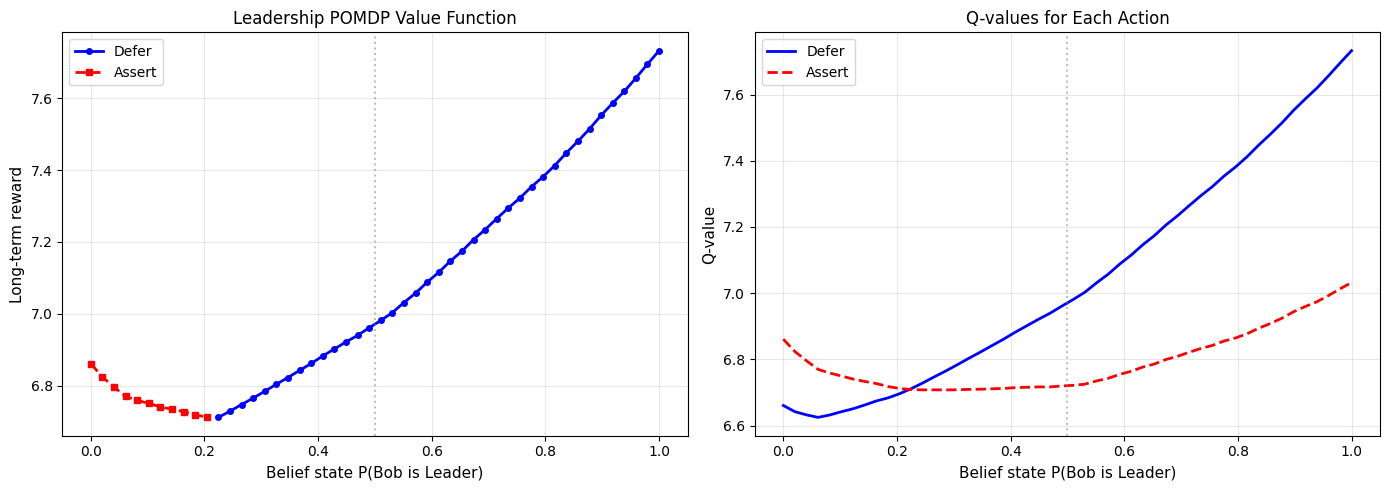


Interpretation:
- When Alice believes Bob is likely a LEADER (high belief), Alice should DEFER
- When Alice believes Bob is likely a FOLLOWER (low belief), Alice should ASSERT
- This creates complementary role coordination!


In [12]:
# Visualize the value function and policy
from matplotlib import pyplot as plt
import numpy as onp

plt.figure(figsize=(14, 5))

# Plot 1: Value function and policy regions
plt.subplot(1, 2, 1)
plt.plot(B[p[:, 0] == 1], v[p[:, 0] == 1], 'b-', label='Defer', linewidth=2, marker='o', markersize=4)
plt.plot(B[p[:, 1] == 1], v[p[:, 1] == 1], 'r--', label='Assert', linewidth=2, marker='s', markersize=4)
plt.xlabel('Belief state P(Bob is Leader)', fontsize=11)
plt.ylabel('Long-term reward', fontsize=11)
plt.title('Leadership POMDP Value Function', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5, label='Uniform belief')

# Plot 2: Q-values for both actions
plt.subplot(1, 2, 2)
plt.plot(B, q[:, 0], 'b-', label='Defer', linewidth=2)
plt.plot(B, q[:, 1], 'r--', label='Assert', linewidth=2)
plt.xlabel('Belief state P(Bob is Leader)', fontsize=11)
plt.ylabel('Q-value', fontsize=11)
plt.title('Q-values for Each Action', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- When Alice believes Bob is likely a LEADER (high belief), Alice should DEFER")
print("- When Alice believes Bob is likely a FOLLOWER (low belief), Alice should ASSERT")
print("- This creates complementary role coordination!")